<a href="https://colab.research.google.com/github/vanshikaav/Startup-Risk-Assessment/blob/main/StartupRiskAssessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h4>Problem Statement : </h4>
The objective of this project is to develop a Startup Failure Risk Assessment System that predicts the likelihood of startup failure using founder behaviour, operational characteristics, financial health, and organizational characteristics.The system provides early risk warnings and actionable insights to help founders, investors, and incubators improve startup survival rates.


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df= pd.read_csv('startup_founder_burnout_2026.csv')

<h3>1. Business Understanding</h3>

**1. What business problem are we solving?**

We are building a system to predict whether a startup is at risk of failure using founder, operational, and financial factors.
The goal is to identify warning signs early before the startup reaches a critical stage.

**2. Why is this problem important?**

A large percentage of startups fail due to issues such as burnout, poor product-market fit, and financial instability.
Early risk prediction enables proactive decisions that can improve startup survival and growth.

**3. Who are the stakeholders?**

The primary stakeholders are startup founders, investors, venture capital firms, incubators, and startup accelerators.
These stakeholders can use the system to assess risk and make more informed strategic decisions.

**4. What decision will our risk assessment help users make?**

The system helps users determine whether a startup requires immediate intervention or corrective action.
It supports decisions related to funding, mentoring, operational improvements, and risk management.


In [52]:
df.head()

,Founder_Type,Economic_Climate,Founder_Age,Founder_Experience_Years,Industry,Funding_Stage,Work_Mode,Team_Size,Startup_Age_Months,Weekly_Work_Hours,...,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Seeks_Mental_Health_Support,Shutdown_Probability,Shutdown_Risk,Startup_Failure_Flag
0,Serial Entrepreneur,Recession,31,12,E-commerce,Seed,Remote,14,99,48.5,...,0,-5.1,5.6,7.8,30.0,9.7,No,0.082,Low,0
1,Calm Operator,Recession,30,0,FinTech,Bootstrapped,Remote,6,47,48.6,...,0,2.7,8.4,2.3,14.4,10.0,No,0.490,Medium,0
2,Burned-Out Operator,Stable Economy,28,3,ClimateTech,Bootstrapped,Hybrid,5,59,68.8,...,0,16.3,4.4,1.0,41.5,4.0,No,0.905,High,1
3,Chaotic Innovator,Stable Economy,32,2,EdTech,Series A,Office,74,143,81.5,...,0,-1.4,31.5,4.0,39.4,5.1,No,0.233,Low,0
4,Growth Obsessed Founder,Stable Economy,35,1,SaaS,Pre-Seed,Hybrid,9,11,78.6,...,0,21.6,7.0,5.2,36.5,4.2,No,0.716,High,1


<h3>2. Data Understanding</h3>
<b>2.1 What are we trying to predict?</b><br>
Our target is <i>Startup_Failure_Flag</i><br>
0 = Startup Survived<br>
1 = Startup Failed<br>
This makes our project a <b>Binary Classification Problem</b> <br><br>

<b>2.2 How many observations do we have?</b><br>
50,000 startup rows<br>
29 features<br><br>

<b>2.3 What does one row represent?</b><br>
One startup-founder profile

In [53]:
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset Shape: 50000 rows × 29 columns


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Founder_Type                    50000 non-null  object 
 1   Economic_Climate                50000 non-null  object 
 2   Founder_Age                     50000 non-null  int64  
 3   Founder_Experience_Years        50000 non-null  int64  
 4   Industry                        50000 non-null  object 
 5   Funding_Stage                   50000 non-null  object 
 6   Work_Mode                       50000 non-null  object 
 7   Team_Size                       50000 non-null  int64  
 8   Startup_Age_Months              50000 non-null  int64  
 9   Weekly_Work_Hours               50000 non-null  float64
 10  Sleep_Hours                     50000 non-null  float64
 11  Exercise_Days_Per_Week          50000 non-null  float64
 12  Vacation_Days_Taken             

In [55]:
df.drop(['Shutdown_Probability','Shutdown_Risk'],axis=1,inplace=True)   #to prevent data leakage

In [56]:
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset Shape: 50000 rows × 27 columns


In [57]:
cat_cols=['Founder_Type','Economic_Climate','Industry','Funding_Stage','Work_Mode','Burnout_Level','Founder_Burnout_Flag','Seeks_Mental_Health_Support',   'Startup_Failure_Flag']

num_cols=['Founder_Age','Founder_Experience_Years','Team_Size', 'Startup_Age_Months', 'Weekly_Work_Hours', 'Sleep_Hours',
       'Exercise_Days_Per_Week', 'Vacation_Days_Taken','Investor_Pressure_Score', 'Cofounder_Conflict_Score', 'Stress_Score',
       'Decision_Fatigue_Score', 'Burnout_Score', 'Monthly_Revenue_Growth_Percent',
       'Runway_Months_Remaining', 'Product_Market_Fit_Score','Employee_Turnover_Percent', 'Work_Life_Balance_Score']

In [58]:
df.isnull().sum()   # no missing vals found

,0
Founder_Type,0
Economic_Climate,0
Founder_Age,0
Founder_Experience_Years,0
Industry,0
Funding_Stage,0
Work_Mode,0
Team_Size,0
Startup_Age_Months,0
Weekly_Work_Hours,0


In [59]:
df.duplicated().sum()   # no duplicate found

np.int64(0)

In [60]:
df['Startup_Failure_Flag'].value_counts()

,count
Startup_Failure_Flag,
0,38133
1,11867


In [61]:
#verifying class imbalance

print("Non-Failure =", df['Startup_Failure_Flag'].value_counts()[0]*100/50000)
print("Failure =",df['Startup_Failure_Flag'].value_counts()[1]*100/50000)

Non-Failure = 76.266
Failure = 23.734


In [62]:
print("Categorical Columns Distribution:\n")
for i in cat_cols:
    print(df[i].value_counts(),"\n\n")

Categorical Columns Distribution:

Founder_Type
Solo Hustler               9010
Technical Builder          8998
Serial Entrepreneur        7045
Growth Obsessed Founder    7014
Visionary CEO              5056
Burned-Out Operator        4932
Chaotic Innovator          3987
Calm Operator              3958
Name: count, dtype: int64 


Economic_Climate
Stable Economy    22416
Funding Winter    11128
Bull Market        9026
Recession          7430
Name: count, dtype: int64 


Industry
AI               8997
SaaS             8991
E-commerce       6002
FinTech          5837
HealthTech       4055
Cybersecurity    4016
EdTech           3982
Gaming           3012
ClimateTech      2586
Biotech          2522
Name: count, dtype: int64 


Funding_Stage
Seed            13465
Pre-Seed        10094
Series A        10003
Bootstrapped     8894
Series B         5010
Series C         2534
Name: count, dtype: int64 


Work_Mode
Remote    22398
Hybrid    19993
Office     7609
Name: count, dtype: int64 


Burno

In [63]:
print("Numerical Columns Distribution:\n")
df.describe()

Numerical Columns Distribution:



,Founder_Age,Founder_Experience_Years,Team_Size,Startup_Age_Months,Weekly_Work_Hours,Sleep_Hours,Exercise_Days_Per_Week,Vacation_Days_Taken,Investor_Pressure_Score,Cofounder_Conflict_Score,Stress_Score,Decision_Fatigue_Score,Burnout_Score,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Startup_Failure_Flag
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.116580,2.62538,54.708660,72.630640,63.703472,5.690506,3.756374,9.256180,6.135680,4.012498,5.114294,4.506346,3.439614,0.107880,5.540454,12.392214,5.330516,35.855618,6.742784,0.237340
std,6.503577,2.10280,112.424631,41.044886,13.160604,1.008238,1.298077,6.514507,2.223854,2.334365,2.502413,2.586042,2.229828,0.310232,14.459565,6.310302,2.406663,16.482813,2.745858,0.425457
min,21.000000,0.00000,1.000000,2.000000,28.000000,2.800000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,-45.000000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,30.000000,1.00000,6.000000,37.000000,54.700000,5.000000,2.900000,4.100000,4.600000,2.300000,3.200000,2.300000,1.200000,0.000000,-3.500000,7.800000,3.600000,23.800000,4.700000,0.000000
50%,34.000000,2.00000,16.000000,73.000000,63.600000,5.700000,3.700000,8.900000,6.200000,4.000000,5.100000,4.200000,3.100000,0.000000,4.000000,12.300000,5.300000,35.000000,7.100000,0.000000
75%,39.000000,4.00000,54.000000,108.000000,72.600000,6.400000,4.600000,13.700000,7.800000,5.600000,6.900000,6.400000,5.000000,0.000000,14.500000,16.700000,7.100000,47.000000,9.300000,0.000000
max,61.000000,12.00000,799.000000,143.000000,110.000000,9.000000,7.000000,35.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,74.700000,36.000000,10.000000,97.600000,10.000000,1.000000


<h3>EDA</h3>

In [64]:
corr_target= df.corr(numeric_only=True)['Startup_Failure_Flag'].sort_values(ascending=False)
print(corr_target)

print("\n\nInterpretation:\n")
print("Higher burnout → higher failure risk\nMore employees leaving → higher failure risk\nMore decision fatigue → higher failure risk\nHigher stress → higher failure risk\nMore cofounder conflict → higher failure risk")

Startup_Failure_Flag              1.000000
Burnout_Score                     0.506236
Employee_Turnover_Percent         0.449765
Decision_Fatigue_Score            0.439155
Stress_Score                      0.425410
Cofounder_Conflict_Score          0.414529
Founder_Burnout_Flag              0.370003
Weekly_Work_Hours                 0.319055
Investor_Pressure_Score           0.159867
Startup_Age_Months                0.000246
Team_Size                        -0.052180
Founder_Age                      -0.063315
Monthly_Revenue_Growth_Percent   -0.100326
Founder_Experience_Years         -0.171051
Vacation_Days_Taken              -0.178751
Exercise_Days_Per_Week           -0.219673
Sleep_Hours                      -0.259755
Runway_Months_Remaining          -0.384222
Product_Market_Fit_Score         -0.386984
Work_Life_Balance_Score          -0.470785
Name: Startup_Failure_Flag, dtype: float64


Interpretation:

Higher burnout → higher failure risk
More employees leaving → higher failure r

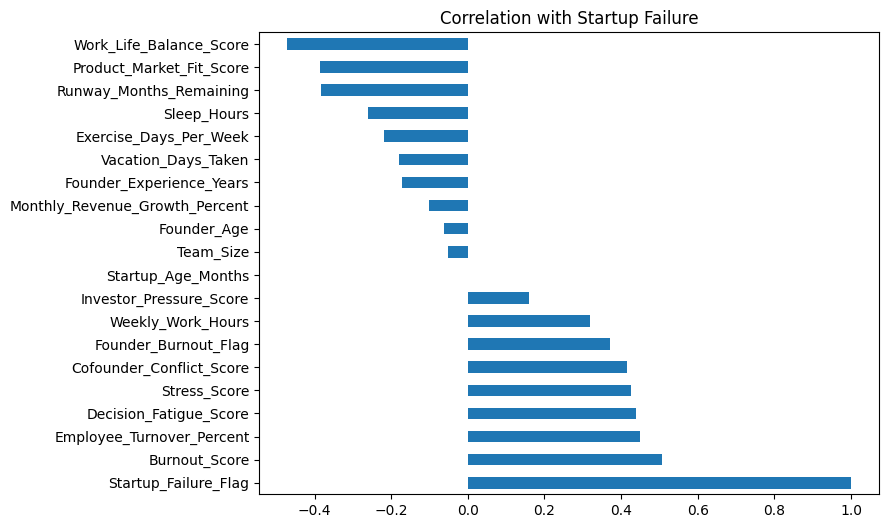

Top positive correlations increase failure risk.
Top negative correlations reduce failure risk.


In [65]:
corr_target.plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Correlation with Startup Failure")
plt.show()

print("Top positive correlations increase failure risk.")
print("Top negative correlations reduce failure risk.")

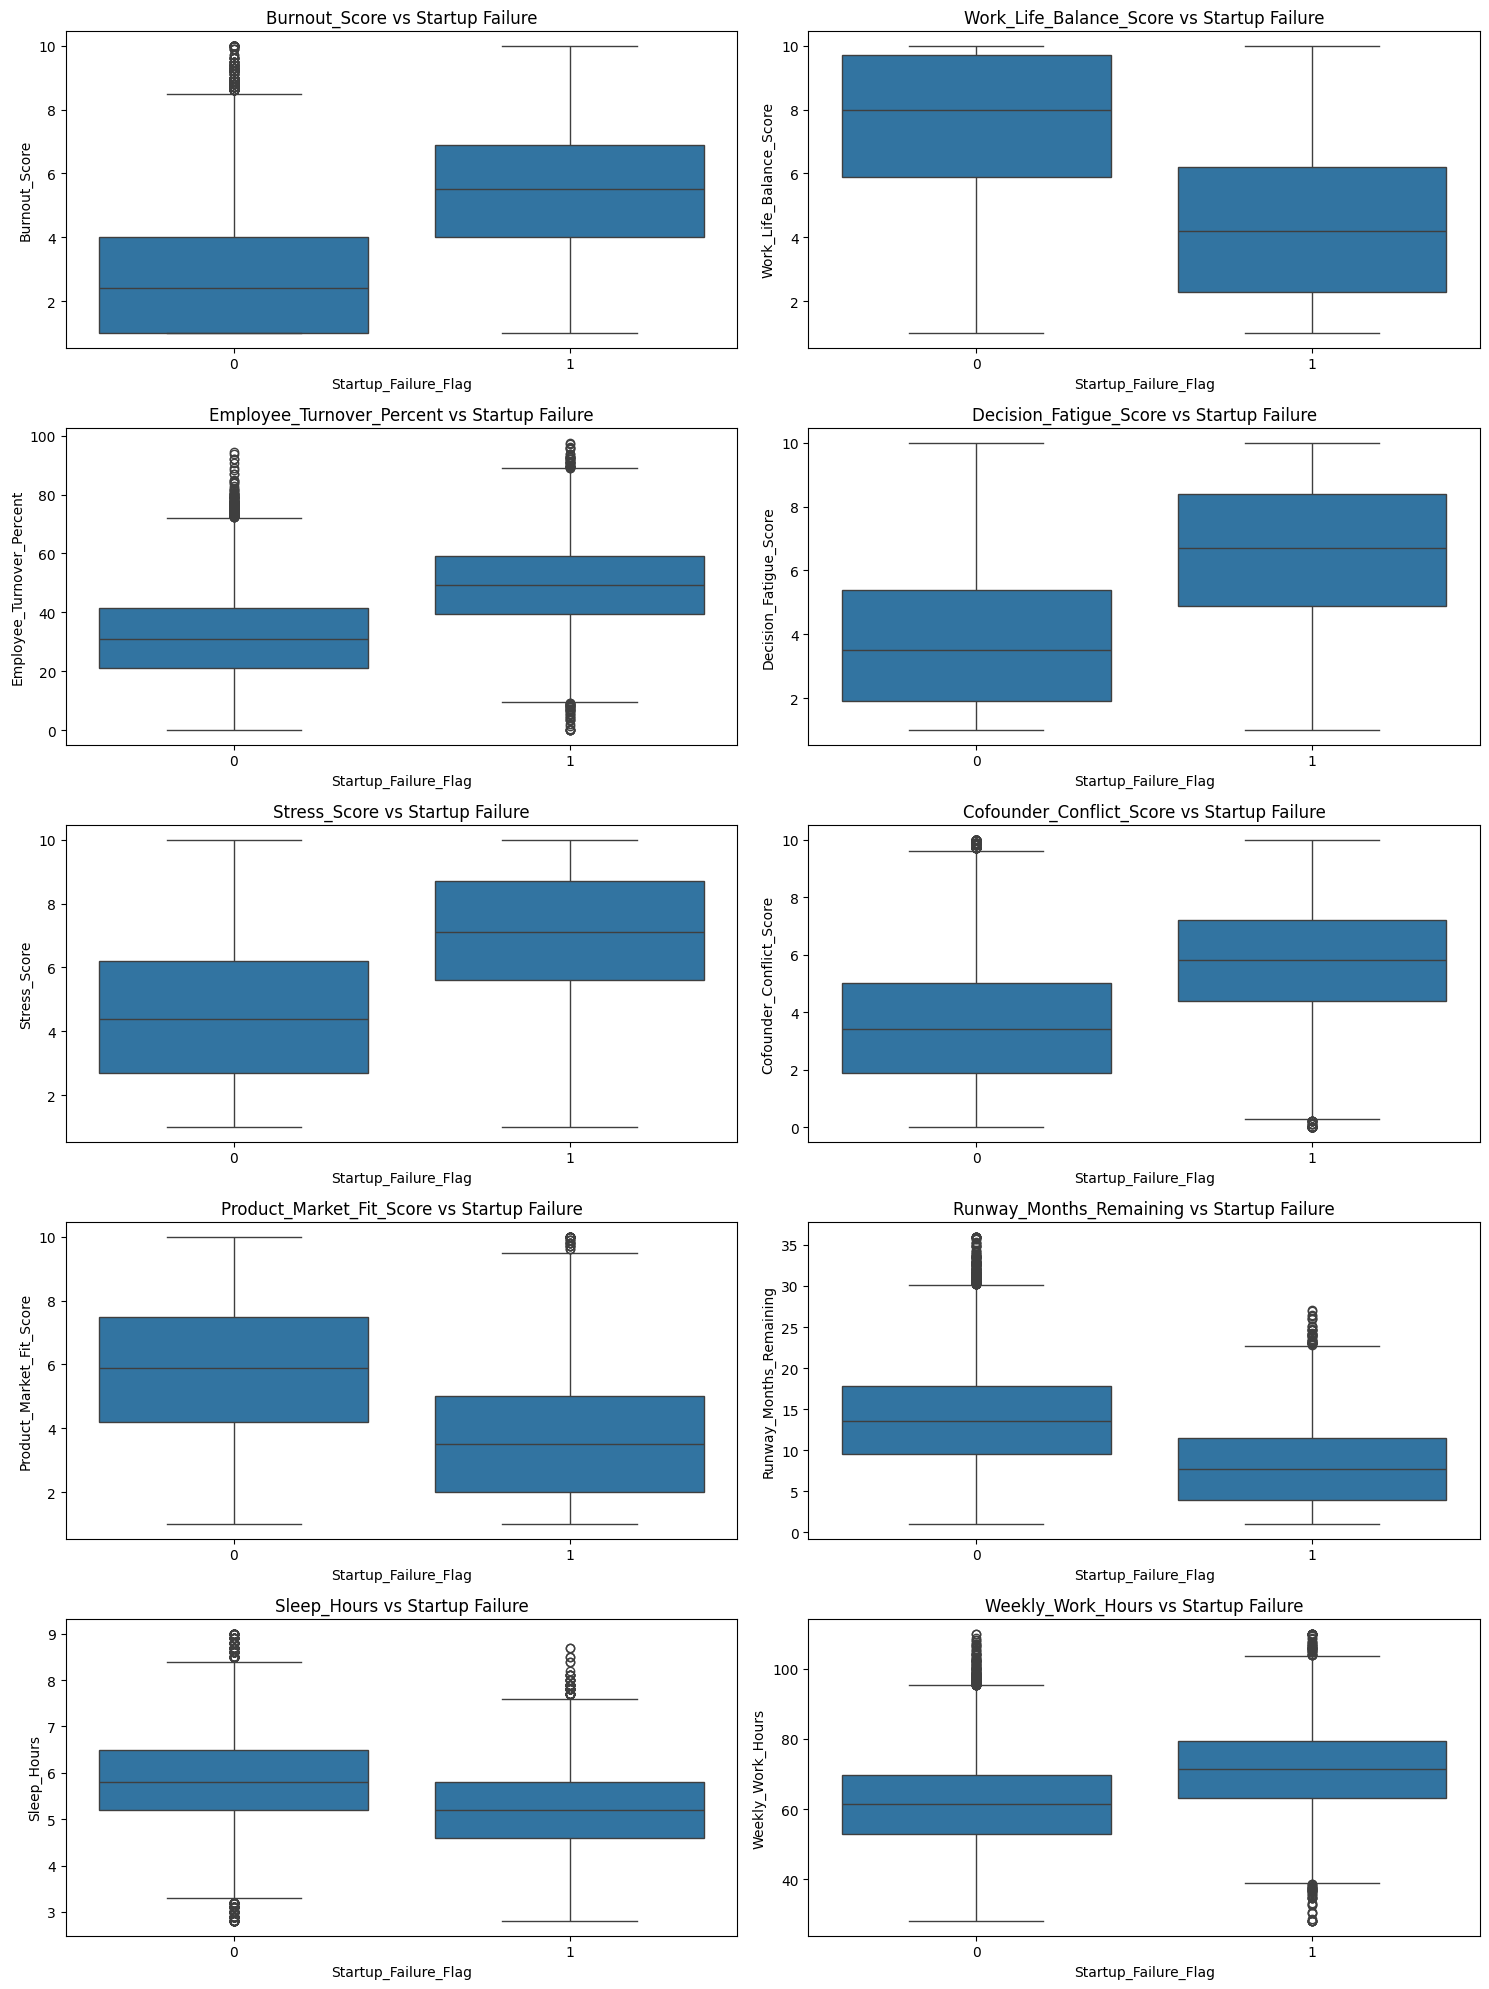

In [66]:
eda_features = [
    'Burnout_Score',
    'Work_Life_Balance_Score',
    'Employee_Turnover_Percent',
    'Decision_Fatigue_Score',
    'Stress_Score',
    'Cofounder_Conflict_Score',
    'Product_Market_Fit_Score',
    'Runway_Months_Remaining',
    'Sleep_Hours',
    'Weekly_Work_Hours'
]

fig, axes = plt.subplots(5,2, figsize=(15,20))

for ax, col in zip(axes.flatten(), eda_features):

    sns.boxplot(
        data=df,
        x='Startup_Failure_Flag',
        y=col,
        ax=ax
    )

    ax.set_title(f'{col} vs Startup Failure')

plt.tight_layout()
plt.show()

In [67]:
for col in eda_features:

    success = df[df['Startup_Failure_Flag']==0][col].mean()
    failure = df[df['Startup_Failure_Flag']==1][col].mean()

    print(f"\n{'='*50}")
    print(f"Feature: {col}")

    print(f"Successful Startups Mean : {success:.2f}")
    print(f"Failed Startups Mean     : {failure:.2f}")

    if failure > success:
        print(f"📈 Higher {col} is associated with startup failure.")
    else:
        print(f"📉 Lower {col} is associated with startup failure.")


Feature: Burnout_Score
Successful Startups Mean : 2.81
Failed Startups Mean     : 5.46
📈 Higher Burnout_Score is associated with startup failure.

Feature: Work_Life_Balance_Score
Successful Startups Mean : 7.46
Failed Startups Mean     : 4.43
📉 Lower Work_Life_Balance_Score is associated with startup failure.

Feature: Employee_Turnover_Percent
Successful Startups Mean : 31.72
Failed Startups Mean     : 49.14
📈 Higher Employee_Turnover_Percent is associated with startup failure.

Feature: Decision_Fatigue_Score
Successful Startups Mean : 3.87
Failed Startups Mean     : 6.54
📈 Higher Decision_Fatigue_Score is associated with startup failure.

Feature: Stress_Score
Successful Startups Mean : 4.52
Failed Startups Mean     : 7.02
📈 Higher Stress_Score is associated with startup failure.

Feature: Cofounder_Conflict_Score
Successful Startups Mean : 3.47
Failed Startups Mean     : 5.75
📈 Higher Cofounder_Conflict_Score is associated with startup failure.

Feature: Product_Market_Fit_Score


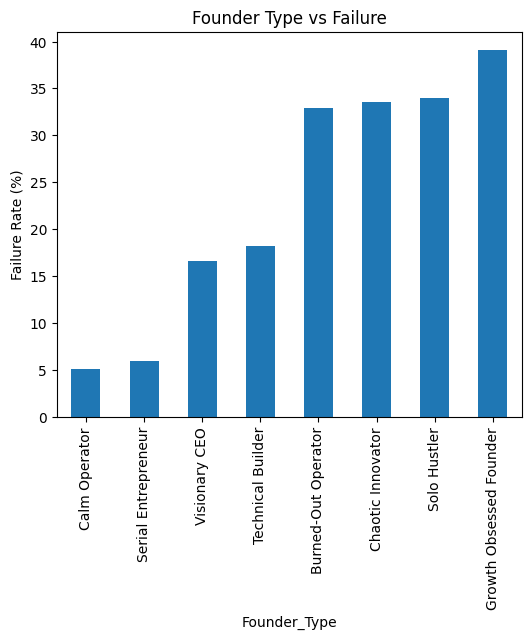

In [68]:
failure_rate = pd.crosstab(
    df['Founder_Type'],
    df['Startup_Failure_Flag'],
    normalize='index'
)*100

failure_rate[1].sort_values().plot(
    kind='bar',
    figsize=(6,5)
)
plt.title("Founder Type vs Failure")
plt.ylabel("Failure Rate (%)")
plt.show()

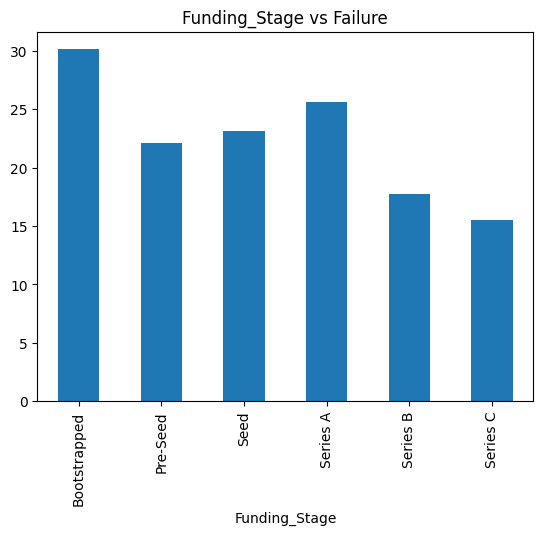

In [69]:
failure_rate = pd.crosstab(
    df['Funding_Stage'],
    df['Startup_Failure_Flag'],
    normalize='index'
)*100

failure_rate[1].plot(kind='bar')
plt.title("Funding_Stage vs Failure")
plt.show()

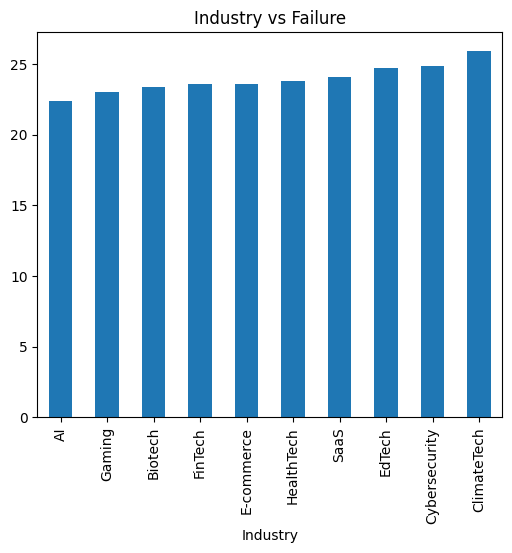

In [70]:
failure_rate = pd.crosstab(
    df['Industry'],
    df['Startup_Failure_Flag'],
    normalize='index'
)*100

failure_rate[1].sort_values().plot(
    kind='bar',
    figsize=(6,5)
)
plt.title("Industry vs Failure")
plt.show()

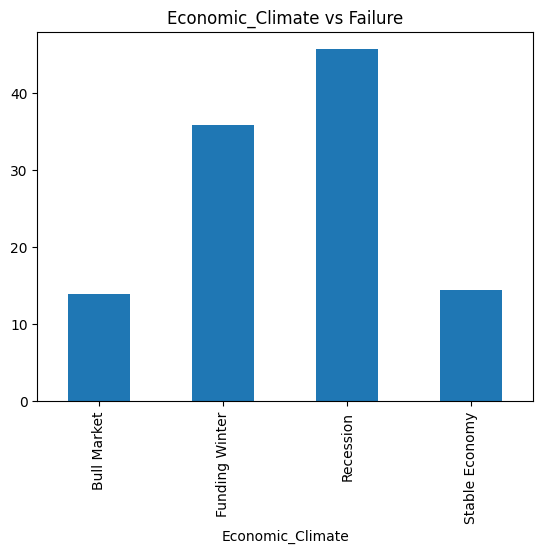

In [71]:
failure_rate = pd.crosstab(
    df['Economic_Climate'],
    df['Startup_Failure_Flag'],
    normalize='index'
)*100

failure_rate[1].plot(kind='bar')
plt.title("Economic_Climate vs Failure")
plt.show()

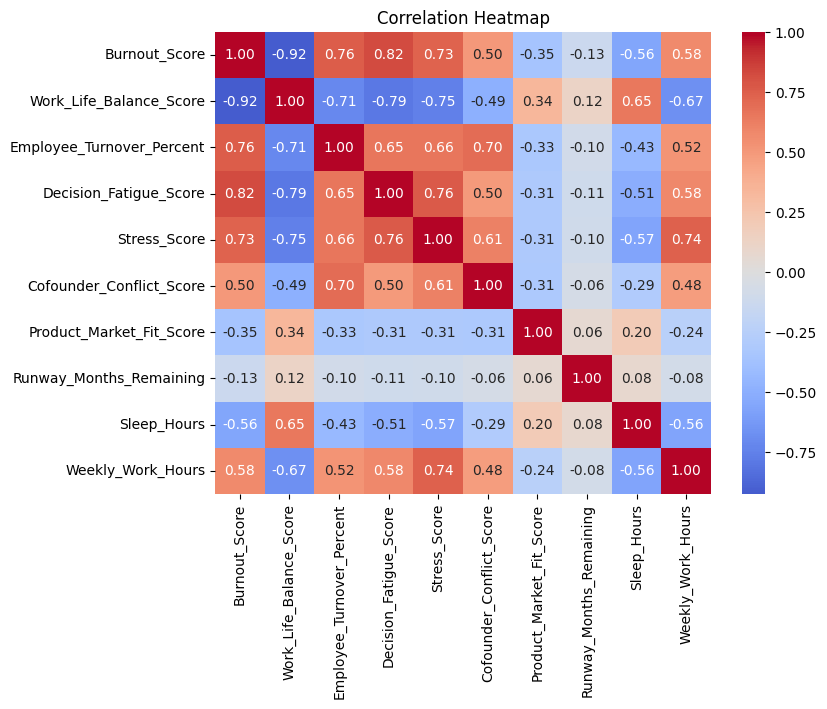

In [26]:
corr_matrix = df[eda_features].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

<h3>Data Preprocessing</h3>
1.Convert all text columns to numbers using LabelEncoder<br>
2.Define our features (X) and target (y)<br>
3.Split data into train and test sets<br><br>



<i>Train set = what the model learns from</i><br>
<i>Test set = how we check if it learned well (unseen data)</i><br>

In [27]:
df.dtypes

,0
Founder_Type,object
Economic_Climate,object
Founder_Age,int64
Founder_Experience_Years,int64
Industry,object
Funding_Stage,object
Work_Mode,object
Team_Size,int64
Startup_Age_Months,int64
Weekly_Work_Hours,float64


In [28]:
df_copy = df.copy()

In [29]:
# feature and target

df_copy.dropna(subset=['Startup_Failure_Flag'], inplace=True)
X = df_copy.drop('Startup_Failure_Flag', axis=1)
y = df_copy['Startup_Failure_Flag']

print("Input features : ",X.shape[0],"rows",X.shape[1],"cols")
print("Output feature : ",y.shape[0],"rows","1","col")

Input features :  50000 rows 26 cols
Output feature :  50000 rows 1 col


In [30]:
#encode categorical features

cat_cols = X.select_dtypes(include='object').columns
print(cat_cols)

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le


Index(['Founder_Type', 'Economic_Climate', 'Industry', 'Funding_Stage',
       'Work_Mode', 'Burnout_Level', 'Seeks_Mental_Health_Support'],
      dtype='object')


In [31]:
X.head()

,Founder_Type,Economic_Climate,Founder_Age,Founder_Experience_Years,Industry,Funding_Stage,Work_Mode,Team_Size,Startup_Age_Months,Weekly_Work_Hours,...,Decision_Fatigue_Score,Burnout_Score,Burnout_Level,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Seeks_Mental_Health_Support
0,4,2,31,12,4,2,2,14,99,48.5,...,2.6,1.0,0,0,-5.1,5.6,7.8,30.0,9.7,0
1,1,2,30,0,6,0,2,6,47,48.6,...,1.7,1.0,0,0,2.7,8.4,2.3,14.4,10.0,0
2,0,3,28,3,2,0,0,5,59,68.8,...,9.0,5.8,1,0,16.3,4.4,1.0,41.5,4.0,0
3,2,3,32,2,5,3,1,74,143,81.5,...,5.4,5.6,1,0,-1.4,31.5,4.0,39.4,5.1,0
4,3,3,35,1,9,1,0,9,11,78.6,...,3.4,4.6,1,0,21.6,7.0,5.2,36.5,4.2,0


In [32]:
X.duplicated().sum()

np.int64(0)

In [33]:
X.dtypes

,0
Founder_Type,int64
Economic_Climate,int64
Founder_Age,int64
Founder_Experience_Years,int64
Industry,int64
Funding_Stage,int64
Work_Mode,int64
Team_Size,int64
Startup_Age_Months,int64
Weekly_Work_Hours,float64


<h3>Model Training</h3>

We work with three models here for the binary classification:
1. Logistic Regression
2. Random Forest
3. Xgboost

In [34]:
# train-test-split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(X,y,
                                                  test_size=0.2,
                                                  random_state=42,
                                                  stratify=y
                                                  )

In [35]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (40000, 26)
X_test : (10000, 26)
y_train: (40000,)
y_test : (10000,)


<h2>Cross Validation + Hyperparameter Tuning</h2>

<h4>Logistic Regression</h4>

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

param_lr = {
    'model__C':[0.01,0.1,1,10]
}

grid_lr = GridSearchCV(
    pipe_lr,
    param_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_lr.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', LogisticRegression())]),
             n_jobs=-1, param_grid={'model__C': [0.01, 0.1, 1, 10]},
             scoring='roc_auc')

<h4>Random Forest Classifier</h4>

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)

param_rf = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,20,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

rf_search = RandomizedSearchCV(
    rf,
    param_rf,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 20, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='roc_auc')

<h4>XGBoost</h4>

In [38]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

param_xgb = {
    'n_estimators':[100,200,300],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.8,1.0],
    'colsample_bytree':[0.8,1.0]
}

xgb_search = RandomizedSearchCV(
    xgb,
    param_xgb,
    cv=5,
    n_iter=20,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='roc_auc')

Insights:

• Hyperparameter tuning improved model performance.<br>
• Cross-validation reduces overfitting risk.<br>
• XGBoost explored multiple tree depths and learning rates.<br>
• Random Forest explored different tree structures.<br>

<h3>Comparing Validation Performance</h3>

In [39]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import roc_auc_score
import pandas as pd

models = {
    "Logistic Regression": grid_lr.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
    "XGBoost": xgb_search.best_estimator_
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8797,0.774906,0.694901,0.732726,0.937034
1,Random Forest,0.8837,0.807419,0.669617,0.732089,0.939695
2,XGBoost,0.8898,0.790847,0.728192,0.758227,0.948333


In [40]:
comparison_cv = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "CV ROC-AUC":[
        grid_lr.best_score_,
        rf_search.best_score_,
        xgb_search.best_score_
    ]
})

comparison_cv.sort_values(
    by="CV ROC-AUC",
    ascending=False
)

,Model,CV ROC-AUC
2,XGBoost,0.951140
1,Random Forest,0.942040
0,Logistic Regression,0.941087


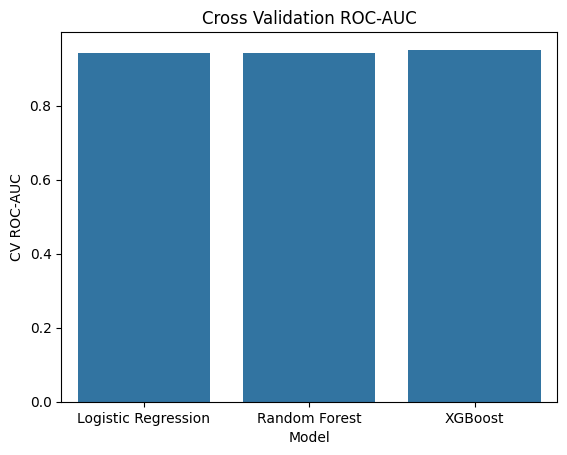

In [41]:
sns.barplot(
    data=comparison_cv,
    x='Model',
    y='CV ROC-AUC'
)
plt.title("Cross Validation ROC-AUC")
plt.show()

In [42]:
best_model = xgb_search.best_estimator_

In [43]:
#final test evaluation

from sklearn.metrics import *

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]


print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision :",precision_score(y_test,y_pred))
print("Recall :",recall_score(y_test,y_pred))
print("F1 :",f1_score(y_test,y_pred))
print("ROC AUC :",roc_auc_score(y_test,y_prob))

Accuracy : 0.8898
Precision : 0.7908466819221968
Recall : 0.7281921618204804
F1 : 0.7582272926722247
ROC AUC : 0.9483334623469054


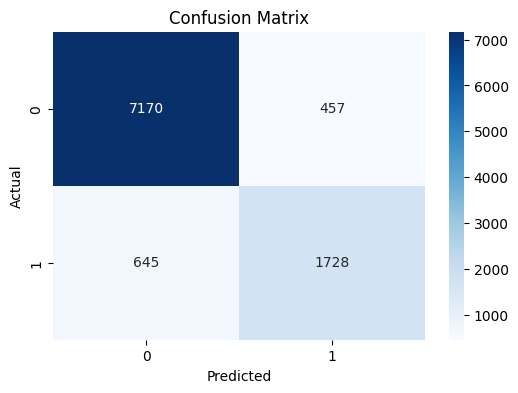

In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Insights:

• The model correctly identifies most failed startups.<br>
• False negatives are limited, reducing the chance of missing high-risk startups.<br>
• Strong ROC-AUC indicates excellent ranking capability.<br>

In [45]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      7627
           1       0.79      0.73      0.76      2373

    accuracy                           0.89     10000
   macro avg       0.85      0.83      0.84     10000
weighted avg       0.89      0.89      0.89     10000



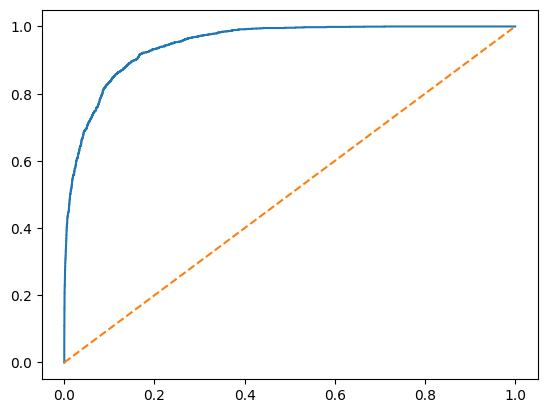

In [46]:
from sklearn.metrics import roc_curve

fpr,tpr,_ = roc_curve(y_test,y_prob)

plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')

Insights:

• ROC curve is significantly above the random baseline.<br>
• Model demonstrates strong discrimination ability.<br>
• High ROC-AUC confirms reliable startup risk ranking.<br>

XGBoost achieved the highest overall performance with the best Accuracy, Precision, Recall, and F1-Score.

Random Forest produced competitive results but slightly underperformed compared to XGBoost.

Logistic Regression served as a baseline model and showed lower performance because startup failure depends on complex non-linear relationships among founder behavior, financial metrics, and operational factors.

<h3>FEATURE IMPORTANCE</h3>
Which variables influence startup failure most?

In [47]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

top20 = importance.sort_values(
    ascending=False
).head(20)

<Axes: >

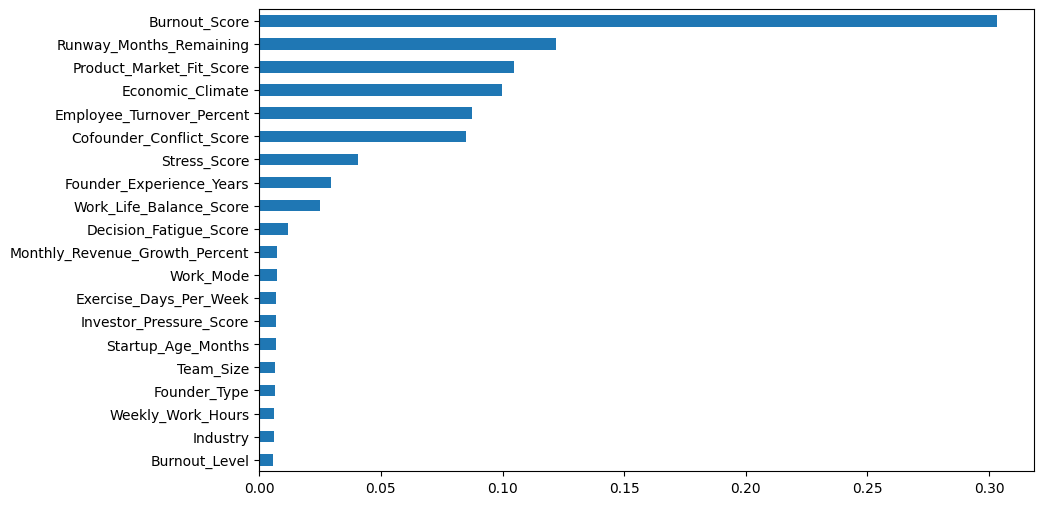

In [48]:
top20.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

Insights:

• Burnout Score is one of the strongest predictors.<br>
• Product-Market Fit strongly reduces failure risk.<br>
• Low runway months increase failure probability.<br>
• Work-Life Balance shows significant influence.<br>

In [49]:
import joblib

joblib.dump(best_model, "startup_failure_model.pkl")

['startup_failure_model.pkl']